In [1]:
# — 1. Imports ——————————————————————————————————————————————————————————
import os, cv2, json, math, random, warnings, hashlib
import numpy as np, pandas as pd
from pathlib import Path
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import timm, albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
SEED=42; random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed(SEED)
DEVICE="cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE, "| timm", timm.__version__)

/usr/local/lib/python3.12/dist-packages/albumentations/check_version.py:147: UserWarning: Error fetching version info <urlopen error [Errno -3] Temporary failure in name resolution>
  data = fetch_version_info()


Device: cuda | timm 1.0.26


In [2]:
# ── 2. Config: your exact dataset paths + label maps ─────────────────
IMG_SIZE     = 299
CANCER_TYPES = ["Melanoma","BCC","SCC","MCC"]
TYPE2IDX     = {c:i for i,c in enumerate(CANCER_TYPES)}
STAGES       = ["Early","Intermediate","Advanced"]
WORK         = Path("/kaggle/working"); WORK.mkdir(exist_ok=True)
IMEXT        = (".jpg",".jpeg",".png",".bmp",".tif",".tiff")

PATHS = {
  "ham_kmader":   "/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000",
  "ham_suraj":    "/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification",
  "isic_all":     "/kaggle/input/datasets/tomooinubushi/all-isic-data-20240629",
  "isic_labelled":"/kaggle/input/datasets/riyaelizashaju/isic-skin-disease-image-dataset-labelled",
  "isic9":        "/kaggle/input/datasets/nodoubttome/skin-cancer9-classesisic",
  "skinds":       "/kaggle/input/datasets/ahmedxc4/skin-ds",
  "dermacon":     "/kaggle/input/datasets/hiro002/dermacon-in-dataset",
  "mccscc":       "/kaggle/input/datasets/mjhapmadushani/mcc-scc",
}

# canonicalise every raw label -> {Melanoma,BCC,SCC,MCC,NONCANCER}
CANON = {
  "mel":"Melanoma","melanoma":"Melanoma","malignant melanoma":"Melanoma",
  "bcc":"BCC","basal cell carcinoma":"BCC",
  "akiec":"SCC","scc":"SCC","squamous cell carcinoma":"SCC","actinic keratosis":"SCC",
  "actinic keratoses":"SCC","bowen":"SCC","intraepithelial carcinoma":"SCC",
  "mcc":"MCC","merkel cell carcinoma":"MCC","merkel":"MCC",
  "nv":"NONCANCER","nevus":"NONCANCER","melanocytic nevi":"NONCANCER","melanocytic nevus":"NONCANCER",
  "bkl":"NONCANCER","benign keratosis":"NONCANCER","pigmented benign keratosis":"NONCANCER",
  "seborrheic keratosis":"NONCANCER","df":"NONCANCER","dermatofibroma":"NONCANCER",
  "vasc":"NONCANCER","vascular lesion":"NONCANCER","benign":"NONCANCER","normal":"NONCANCER",
}
def canon(x):
    if x is None or (isinstance(x,float) and math.isnan(x)): return None
    return CANON.get(str(x).strip().lower(), None)
def is_cancer(l): return 0 if l=="NONCANCER" else 1

for k,v in PATHS.items():
    print(f"{k:14} exists={Path(v).exists()}  {v}")

ham_kmader     exists=True  /kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000
ham_suraj      exists=True  /kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification
isic_all       exists=True  /kaggle/input/datasets/tomooinubushi/all-isic-data-20240629
isic_labelled  exists=True  /kaggle/input/datasets/riyaelizashaju/isic-skin-disease-image-dataset-labelled
isic9          exists=True  /kaggle/input/datasets/nodoubttome/skin-cancer9-classesisic
skinds         exists=True  /kaggle/input/datasets/ahmedxc4/skin-ds
dermacon       exists=True  /kaggle/input/datasets/hiro002/dermacon-in-dataset
mccscc         exists=True  /kaggle/input/datasets/mjhapmadushani/mcc-scc


In [3]:
# ── 3. Discover attached data (counts + csv columns) ─────────────────
def scan(root):
    root=Path(root)
    if not root.exists(): print("   (missing)"); return
    imgs=[p for p in root.rglob("*") if p.suffix.lower() in IMEXT]
    csvs=list(root.rglob("*.csv"))
    print(f"   images={len(imgs):>7}  csvs={len(csvs)}  sample={imgs[0].relative_to(root) if imgs else '-'}")
    for c in csvs[:3]:
        try: print("      csv:", c.name, "->", list(pd.read_csv(c,nrows=1).columns)[:8])
        except Exception as e: print("      csv err", e)
for k,v in PATHS.items():
    print("="*60,"\n",k); scan(v)

 ham_kmader
   images=  20030  csvs=5  sample=HAM10000_images_part_1/ISIC_0028933.jpg
      csv: hmnist_8_8_RGB.csv -> ['pixel0000', 'pixel0001', 'pixel0002', 'pixel0003', 'pixel0004', 'pixel0005', 'pixel0006', 'pixel0007']
      csv: hmnist_28_28_RGB.csv -> ['pixel0000', 'pixel0001', 'pixel0002', 'pixel0003', 'pixel0004', 'pixel0005', 'pixel0006', 'pixel0007']
      csv: hmnist_8_8_L.csv -> ['pixel0000', 'pixel0001', 'pixel0002', 'pixel0003', 'pixel0004', 'pixel0005', 'pixel0006', 'pixel0007']
 ham_suraj
   images=  20030  csvs=1  sample=images/ISIC_0030912.jpg
      csv: GroundTruth.csv -> ['image', 'MEL', 'NV', 'BCC', 'AKIEC', 'BKL', 'DF', 'VASC']
 isic_all
   images=  81722  csvs=1  sample=images/ISIC_2801761.jpg
      csv: metadata.csv -> ['isic_id', 'attribution', 'copyright_license', 'acquisition_day', 'age_approx', 'anatom_site_general', 'benign_malignant', 'clin_size_long_diam_mm']
 isic_labelled
   images=  25331  csvs=0  sample=ISIC_Labelled/Melanoma/ISIC_0014233_downsampled

In [4]:
# ── 4. Build ONE unified manifest across all 8 datasets ──────────────
records=[]
def add(path,raw,source,group=None):
    l=canon(raw)
    if l is None: return
    records.append({"path":str(path),"label":l,"source":source,
                    "group":group if group is not None else Path(path).stem})

def harvest_ham(root, source):
    root=Path(root); n0=len(records)
    if not root.exists(): return
    imgs={p.stem:p for p in root.rglob("*") if p.suffix.lower() in IMEXT}
    for c in root.rglob("*.csv"):
        try: df=pd.read_csv(c)
        except Exception: continue
        df.columns=df.columns.str.lower()
        if not {"image_id","dx"}.issubset(df.columns): continue
        gcol="lesion_id" if "lesion_id" in df.columns else "image_id"
        for _,r in df.iterrows():
            p=imgs.get(str(r["image_id"]))
            if p is not None: add(p, r["dx"], source, group=str(r[gcol]))
    print(f"[{source}] +{len(records)-n0}")

def harvest_csv(root, source):
    root=Path(root); n0=len(records)
    if not root.exists(): return
    imgs={p.stem:p for p in root.rglob("*") if p.suffix.lower() in IMEXT}
    for c in root.rglob("*.csv"):
        try: df=pd.read_csv(c, low_memory=False)
        except Exception: continue
        df.columns=df.columns.str.lower()
        idc=next((x for x in ["isic_id","image_id","image","name","id","filename"] if x in df.columns),None)
        dgc=next((x for x in ["diagnosis","dx","label","class","benign_malignant","diagnosis_1"] if x in df.columns),None)
        if not idc or not dgc: continue
        for _,r in df.iterrows():
            stem=str(r[idc]).rsplit(".",1)[0]
            p=imgs.get(stem)
            if p is not None and canon(r[dgc]) is not None:
                add(p, r[dgc], source)
    print(f"[{source}] +{len(records)-n0} (csv)")

def harvest_folders(root, source):
    root=Path(root); n0=len(records)
    if not root.exists(): return
    for p in root.rglob("*"):
        if p.suffix.lower() in IMEXT and canon(p.parent.name) is not None:
            add(p, p.parent.name, source)
    print(f"[{source}] +{len(records)-n0} (folders)")

# HAM (metadata csv)
harvest_ham(PATHS["ham_kmader"], "HAM10000")
harvest_ham(PATHS["ham_suraj"],  "HAM10000-seg")
# ISIC (csv-based)
harvest_csv(PATHS["isic_all"],   "ISIC-all")
# folder-named class datasets
harvest_folders(PATHS["isic_labelled"], "ISIC-labelled")
harvest_folders(PATHS["isic9"],         "ISIC-9class")
harvest_folders(PATHS["skinds"],        "skin-ds")
harvest_folders(PATHS["dermacon"],      "DermaCon-IN")
harvest_folders(PATHS["mccscc"],        "MCC-SCC")
# also try csv for the folder sets in case they ship a labels csv
for k in ["isic_labelled","isic9","skinds","dermacon","mccscc"]:
    harvest_csv(PATHS[k], k+"-csv")

raw=pd.DataFrame(records).drop_duplicates("path").reset_index(drop=True)
assert len(raw)>0, "No images mapped — check Section 3 output / adjust loaders."
print("\nTOTAL:", len(raw))
print(raw.groupby(["label","source"]).size().unstack(fill_value=0))

[HAM10000] +10015
[HAM10000-seg] +0
[ISIC-all] +51739 (csv)
[ISIC-labelled] +25331 (folders)
[ISIC-9class] +4714 (folders)
[skin-ds] +22454 (folders)
[DermaCon-IN] +0 (folders)
[MCC-SCC] +0 (folders)
[isic_labelled-csv] +0 (csv)
[isic9-csv] +0 (csv)
[skinds-csv] +0 (csv)
[dermacon-csv] +0 (csv)
[mccscc-csv] +0 (csv)

TOTAL: 114253
source     HAM10000  ISIC-9class  ISIC-all  ISIC-labelled  skin-ds
label                                                             
BCC             514          784      4921           3323     3323
Melanoma       1113          908      7349           4522     4522
NONCANCER      8061         2368     36730          15991    13114
SCC             327          654      2739           1495     1495


In [5]:
# ── 5. MD5 de-dup + OFFLINE MCC AUGMENTATION (balance the rare class) ─
def md5(p):
    try:
        with open(p,"rb") as f: return hashlib.md5(f.read()).hexdigest()
    except Exception: return None

raw["h"]=raw["path"].map(md5); raw=raw.drop_duplicates("h").drop(columns="h").reset_index(drop=True)

MCC_TARGET=300
mcc=raw[raw.label=="MCC"]; print("Real MCC:", len(mcc))

aug=A.Compose([
    A.RandomRotate90(),
    A.HorizontalFlip(p=0.5), 
    A.VerticalFlip(p=0.5),
    A.ShiftScaleRotate(0.08,0.15,35,p=0.9,border_mode=cv2.BORDER_REFLECT),
    A.RandomBrightnessContrast(0.2,0.2,p=0.8),
    A.HueSaturationValue(10,15,10,p=0.6),
    A.CoarseDropout(max_holes=6,max_height=24,max_width=24,p=0.4),
    A.ElasticTransform(alpha=1,sigma=30,alpha_affine=25,p=0.3)
])

ad=WORK/"mcc_aug"; ad.mkdir(exist_ok=True); new=[]
if len(mcc)>0:
    src=mcc["path"].tolist(); need=max(0,MCC_TARGET-len(mcc)); i=0
    while len(new)<need:
        sp=src[i%len(src)]; i+=1; im=cv2.imread(sp)
        if im is None: continue
        im=cv2.cvtColor(im,cv2.COLOR_BGR2RGB); o=aug(image=im)["image"]
        op=ad/f"mcc_{len(new):04d}.jpg"; cv2.imwrite(str(op),cv2.cvtColor(o,cv2.COLOR_RGB2BGR))
        new.append({"path":str(op),"label":"MCC","source":"MCC_aug","group":f"mccaug{len(new)}"})
    print("Generated", len(new), "MCC ->", len(mcc)+len(new))

data=pd.concat([raw,pd.DataFrame(new)],ignore_index=True) if new else raw.copy()
data["is_cancer"]=data.label.map(is_cancer); data["type_idx"]=data.label.map(lambda l:TYPE2IDX.get(l,-1))
print(data.groupby("label").size())

Real MCC: 0
label
BCC           8615
Melanoma     12275
NONCANCER    53302
SCC           4542
dtype: int64


Skin-tone distribution (III–V = South-Asian focus):
tone
I      43809
II      8192
III     5630
IV      5650
V       4382
VI     11071
Name: count, dtype: int64


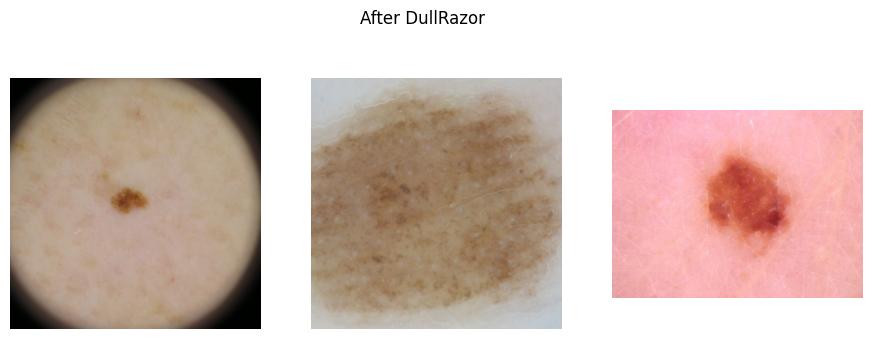

In [6]:
# ── 6. Preprocessing (DullRazor) + ITA° SKIN TONE (South-Asian aware) ─
def dullrazor(rgb):
    g=cv2.cvtColor(rgb,cv2.COLOR_RGB2GRAY)
    k=cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(9,9))
    bh=cv2.morphologyEx(g,cv2.MORPH_BLACKHAT,k)
    _,m=cv2.threshold(bh,10,255,cv2.THRESH_BINARY)
    return cv2.inpaint(rgb,m,6,cv2.INPAINT_TELEA)

def read_rgb(path, hair=True):
    im=cv2.imread(path)
    if im is None: return np.full((IMG_SIZE,IMG_SIZE,3),127,np.uint8)
    im=cv2.cvtColor(im,cv2.COLOR_BGR2RGB)
    if hair:
        try: im=dullrazor(im)
        except Exception: pass
    return im

def ita_degree(rgb):
    """Individual Typology Angle on border (healthy-skin) pixels."""
    h,w,_=rgb.shape; b=max(4,min(h,w)//20)
    border=np.concatenate([rgb[:b].reshape(-1,3),rgb[-b:].reshape(-1,3),
                           rgb[:,:b].reshape(-1,3),rgb[:,-b:].reshape(-1,3)])
    lab=cv2.cvtColor(border.reshape(1,-1,3).astype(np.uint8),cv2.COLOR_RGB2LAB).reshape(-1,3).astype(np.float32)
    L=lab[:,0]*100.0/255.0; bstar=lab[:,2]-128.0
    ita=np.degrees(np.arctan2(L-50.0, bstar+1e-6))
    return float(np.median(ita))

def tone_band(ita):
    if ita>55: return "I"      # very light
    if ita>41: return "II"     # light
    if ita>28: return "III"    # intermediate  (South-Asian)
    if ita>10: return "IV"     # tan           (South-Asian)
    if ita>-30:return "V"      # brown         (South-Asian)
    return "VI"                # dark

def blur_score(rgb):
    return float(cv2.Laplacian(cv2.cvtColor(rgb,cv2.COLOR_RGB2GRAY),cv2.CV_64F).var())

# compute tone + blur once (sample-safe on large sets: full pass but cheap)
itas=[]; bands=[]; blurs=[]
for p in data["path"]:
    im=read_rgb(p, hair=False)
    itas.append(ita_degree(im)); bands.append(tone_band(itas[-1])); blurs.append(blur_score(im))
data["ita"]=itas; data["tone"]=bands; data["blur"]=blurs
print("Skin-tone distribution (III–V = South-Asian focus):")
print(data["tone"].value_counts().sort_index())
# quick visual
fig,ax=plt.subplots(1,3,figsize=(11,4))
for a,p in zip(ax,data.sample(3,random_state=1)["path"]): a.imshow(read_rgb(p)); a.axis("off")
plt.suptitle("After DullRazor"); plt.show()